# Regression Task on Taiwan Air Quality Index Dataset

Link to Dataset: https://www.kaggle.com/datasets/taweilo/taiwan-air-quality-data-20162024

## 0 Imports

In [1]:
#%pip install kagglehub

In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import os
import kagglehub
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn
from sklearn.impute import KNNImputer
# Config Files and Python Modules

/home/jakob/Dokumente/ML Repo/184.702_MachineLearning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 Load and Explore Dataset

### 1.1 Load Raw Data

In [3]:
data_root = os.path.abspath("../data")
os.makedirs(data_root, exist_ok=True)
local_csv = os.path.join(data_root, "air_quality.csv")

def _find_csv(directory):
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith('.csv'):
                return os.path.join(root, f)
    return None

if not os.path.isfile(local_csv):
    print("Downloading Taiwan Air Quality Data from Kaggle...")
    download_path = kagglehub.dataset_download("taweilo/taiwan-air-quality-data-20162024")
    csv_path = None
    if os.path.isdir(download_path):
        csv_path = _find_csv(download_path)
    elif zipfile.is_zipfile(download_path):
        with zipfile.ZipFile(download_path) as archive:
            archive.extractall(data_root)
        csv_path = _find_csv(data_root)
        os.remove(download_path)
    else:
        csv_path = download_path
    if csv_path is None or not os.path.isfile(csv_path):
        raise FileNotFoundError("Could not locate air_quality csv after download.")
    if os.path.abspath(csv_path) != os.path.abspath(local_csv):
        os.replace(csv_path, local_csv)

print("Reading Taiwan Air Quality Data...")
data = pd.read_csv(local_csv, encoding='utf-8')
#print name of all columns
data.head()



Reading Taiwan Air Quality Data...


/tmp/ipykernel_32612/2287108026.py:31: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(local_csv, encoding='utf-8')


,date,sitename,county,aqi,pollutant,status,so2,co,o3,o3_8hr,...,windspeed,winddirec,unit,co_8hr,pm2.5_avg,pm10_avg,so2_avg,longitude,latitude,siteid
0,2024-08-31 23:00,Hukou,Hsinchu County,62.0,PM2.5,Moderate,0.9,0.17,35.0,40.2,...,2.3,225,NaN,0.2,20.1,26.0,1.0,121.038869,24.900097,22.0
1,2024-08-31 23:00,Zhongming,Taichung City,50.0,NaN,Good,1.6,0.32,27.9,35.1,...,1.1,184,NaN,0.2,15.3,23.0,1.0,120.641092,24.151958,31.0
2,2024-08-31 23:00,Zhudong,Hsinchu County,45.0,NaN,Good,0.4,0.17,25.1,40.6,...,0.4,210,NaN,0.2,13.8,24.0,0.0,121.088955,24.740914,23.0
3,2024-08-31 23:00,Hsinchu,Hsinchu City,42.0,NaN,Good,0.8,0.2,30.0,35.9,...,1.9,239,NaN,0.2,13.0,26.0,1.0,120.972368,24.805636,24.0
4,2024-08-31 23:00,Toufen,Miaoli County,50.0,NaN,Good,1.0,0.16,33.5,35.9,...,1.8,259,NaN,0.1,15.3,28.0,1.0,120.898693,24.696907,25.0


### 1.2 Initial Data Overview

In [ ]:
#check for duplicates
print(f"Number of duplicate rows: {data.duplicated().sum()}")



#split into features and target
X = data.drop(columns=['date', 'sitename', 'county', 'aqi', 'pollutant' , 'status', 'unit', 'longitude', 'latitude', 'siteid'])
y = data['aqi']

#convert all columns to numeric, coerce errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')
Y= y.apply(pd.to_numeric, errors='coerce')

print("Initial Y shape:", Y.shape)
#exclude y NaN values from X and Y
valid_indices = Y.notnull()
X = X[valid_indices]
Y = Y[valid_indices]

print("Y shape after removing NaN values:", Y.shape)

Number of duplicate rows: 0


### 1.3 Exploratory Data Analysis if interesting

In [5]:
# Display basic information about the dataset
# print(data.info())
# print(data.head())
# print(data.describe())


#### 1.3.1 Histograms

In [ ]:
#Distribution of target variable 'aqi'
plt.figure(figsize=(10, 6))
sns.histplot(Y, bins=50, kde=True)
plt.title('Distribution of Air Quality Index (AQI)')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

#### 1.3.2 Correlations

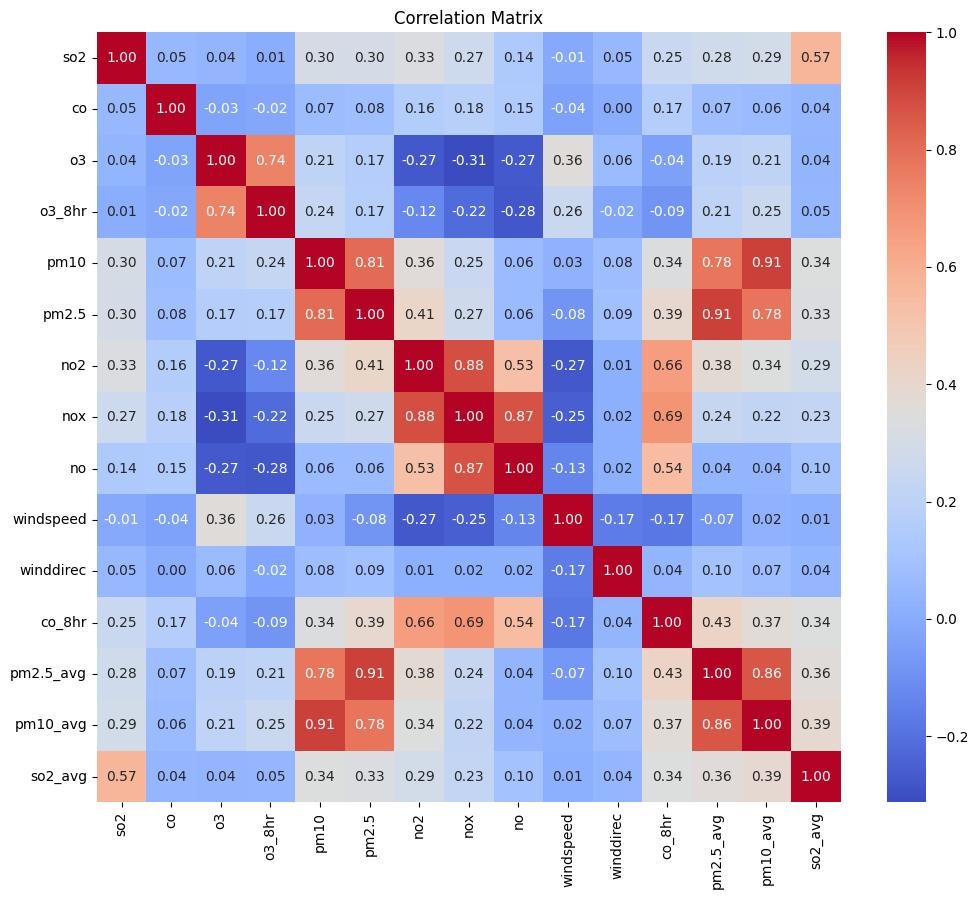

In [6]:
# correlation matrix


plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### 1.3.3 Visualizations

In [7]:
#print statistics of each feature
print(X.describe())
print(Y.describe())

                so2            co            o3        o3_8hr          pm10  \
count  5.720319e+06  5.705892e+06  5.654626e+06  5.713535e+06  5.717758e+06   
mean   1.992542e+00  3.385905e-01  3.041863e+01  3.035164e+01  3.438834e+01   
std    1.875875e+00  1.209309e+00  1.835725e+01  1.585386e+01  2.429178e+01   
min   -9.990000e+02 -9.990000e+02 -9.990000e+02 -1.000000e+00 -9.990000e+02   
25%    1.000000e+00  1.900000e-01  1.600000e+01  1.800000e+01  1.800000e+01   
50%    1.600000e+00  2.900000e-01  2.820000e+01  2.900000e+01  2.800000e+01   
75%    2.500000e+00  4.100000e-01  4.200000e+01  4.100000e+01  4.500000e+01   
max    2.554000e+02  3.858000e+01  4.100000e+02  1.358000e+02  1.407000e+03   

              pm2.5           no2           nox            no     windspeed  \
count  5.663366e+06  5.694510e+06  5.693934e+06  5.693598e+06  5.559236e+06   
mean   1.684841e+01  1.125169e+01  1.471646e+01  3.449846e+00  2.212753e+00   
std    1.271172e+01  8.677392e+00  1.488188e+01  8.

## 2 Data Cleaning and Preprocessing

### 2.1 Missing Values

In [8]:
#missing values
print("Missing values in each column:")
print(X.isnull().sum())
print("Missing values in target variable:")
print(Y.isnull().sum())


Missing values in each column:
so2          118869
co           133296
o3           184562
o3_8hr       125653
pm10         121430
pm2.5        175822
no2          144678
nox          145254
no           145590
windspeed    279952
winddirec    280206
co_8hr        78214
pm2.5_avg     46833
pm10_avg      62838
so2_avg      603527
dtype: int64
Missing values in target variable:
0


### 2.2 Train/Test Split

In [9]:
#train test split
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
y_binned = pd.cut(Y, bins=5, labels=False)


X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X, Y, test_size=0.99, random_state=42, stratify=y_binned)


y_binned_small = pd.cut(y_train_small, bins=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(X_train_small, y_train_small, test_size=0.2, random_state=42, stratify=y_binned_small) 

### 2.3 Scaling and Encoding Pipelines

not sure if scaling is needed will be implemented in the pipeline later on


## 3 Train and Evaluate Baseline Models (sklearn)


### 3.1 Define Model Pipelines


In [10]:
#define a pipeline with knn imputer and standard scaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
   ('scaler', StandardScaler())
])

#fit and transform the training data, transform the test data
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)


scaler_y = StandardScaler()


y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_test_scaled = scaler_y.transform(y_test_reshaped)


y_train = y_train_scaled.flatten()
y_test = y_test_scaled.flatten()

y_train = pd.DataFrame(y_train, columns=['aqi'])
y_test = pd.DataFrame(y_test, columns=['aqi'])

y_train = y_train['aqi']
y_test = y_test['aqi']

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)


#print the shape of the training and test data
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of test data: {X_test.shape}")
print(X_train.describe())
print(X_test.describe())
#show type of X_train colums



print(y_train.describe())
#print missing values in training and test data
print("__________________________")
print("Missing values in training and test data after imputation:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Shape of training data: (46712, 15)
Shape of test data: (11679, 15)
                so2            co            o3        o3_8hr          pm10  \
count  4.671200e+04  4.671200e+04  4.671200e+04  4.671200e+04  4.671200e+04   
mean   2.798850e-17 -5.536855e-17 -2.254291e-16 -8.548660e-17  5.673755e-17   
std    1.000011e+00  1.000011e+00  1.000011e+00  1.000011e+00  1.000011e+00   
min   -1.460942e+00 -1.497276e+00 -1.701468e+00 -1.934798e+00 -1.444746e+00   
25%   -5.249594e-01 -5.707043e-01 -7.819306e-01 -7.847825e-01 -6.915540e-01   
50%   -1.739660e-01 -2.081326e-01 -7.288965e-02 -8.199543e-02 -2.312700e-01   
75%    2.940252e-01  2.752963e-01  6.084544e-01  6.207916e-01  4.382339e-01   
max    5.621897e+01  1.647016e+01  5.688068e+00  5.604191e+00  1.437228e+01   

              pm2.5           no2           nox            no     windspeed  \
count  4.671200e+04  4.671200e+04  4.671200e+04  4.671200e+04  4.671200e+04   
mean  -7.240502e-17 -6.206145e-17 -1.131709e-16 -4.685031e-17 

### 3.2 Cross-Validation Setup


In [11]:
#nicht aurfufen, da zu lange Laufzeit
#

if False:

    # Hyperparameter Tuning with RandomizedSearchCV


        from importlib import reload
        import config

        from sklearn.model_selection import RandomizedSearchCV
        from sklearn.pipeline import Pipeline   

        config = reload(config)

        BASELINE_MODELS = config.BASELINE_MODELS
        PARAM_DISTS = config.PARAM_DISTS
        SCORING_METRICS = config.SCORING_METRICS
        RANDOM_SEED = config.RANDOM_SEED
        CV_FOLDS = config.CV_FOLDS

        results = {}
        for name, estimator in BASELINE_MODELS.items():
            if name not in PARAM_DISTS:
                continue
            if name == 'random_forest':
                njobs= 1
                n_iter=40
                X_train_run = X_train_small
                y_train_run = y_train_small
            else:
                njobs= 8
                n_iter=40
                X_train_run = X_train_small
                y_train_run = y_train_small
            print(f'Running RandomizedSearchCV for {name}...')
            pipeline = Pipeline([('model', estimator)])
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=PARAM_DISTS[name],
                scoring=SCORING_METRICS,
                refit='rmse',
                n_iter=n_iter,
                cv=CV_FOLDS,
                verbose=3,
                random_state=RANDOM_SEED,
                n_jobs=njobs
            )
            search.fit(X_train_run, y_train_run)
            results[name] = search
                
                
        
            print(f'Best RMSE (negated) for {name}: {search.best_score_:.4f}')
            print('Best params:', search.best_params_)

        # Access results dict for later inspection, e.g., results['random_forest'].cv_results_


In [12]:
best_parameters = {
  'decision_tree': {
    'model__criterion': 'squared_error',
    'model__max_depth': 22,
    'model__min_samples_leaf': 2,
    'model__min_samples_split': 16},
 'decision_tree2': {
   'model__criterion': 'squared_error',
    'model__max_depth': 22,
    'model__min_samples_leaf': 2,
    'model__min_samples_split': 16},
 'random_forest': {
   'model__bootstrap': True,
    'model__criterion': 'squared_error',
    'model__max_depth': 34,
    'model__max_features': None,
    'model__min_samples_leaf': 5,
    'model__min_samples_split': 11,
     'model__n_estimators': 430},
 'random_forest2': {
   'model__criterion': 'squared_error',
    'model__max_depth': 50,
    'model__min_samples_leaf': 1,
    'model__min_samples_split': 2,
    'model__n_estimators': 1000}
 }

### 3.3  KFold Crossvalidation


In [13]:
#Train best models with best parameters found on k-fold crossvalidation datasets

from importlib import reload
import config


config = reload(config)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


BASELINE_MODELS = config.BASELINE_MODELS
PARAM_DISTS = config.PARAM_DISTS
SCORING_METRICS = config.SCORING_METRICS
RANDOM_SEED = config.RANDOM_SEED
CV_FOLDS = config.CV_FOLDS


linear_regressor = Pipeline([
   
    ("model", BASELINE_MODELS["linear"]),
])

best_decision_tree = Pipeline([ 
    ("model", DecisionTreeRegressor(
        criterion=best_parameters['decision_tree']['model__criterion'],
        max_depth=best_parameters['decision_tree']['model__max_depth'],
        min_samples_leaf=best_parameters['decision_tree']['model__min_samples_leaf'],
        min_samples_split=best_parameters['decision_tree']['model__min_samples_split'],
        random_state=RANDOM_SEED,
    )),
])

best_random_forest = Pipeline([
       ("model", RandomForestRegressor(
        criterion=best_parameters['random_forest']['model__criterion'],
        max_depth=best_parameters['random_forest']['model__max_depth'],
        min_samples_leaf=best_parameters['random_forest']['model__min_samples_leaf'],
        min_samples_split=best_parameters['random_forest']['model__min_samples_split'],
        n_estimators=best_parameters['random_forest']['model__n_estimators'],
        bootstrap=True,
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

standard_random_forest = Pipeline([
      ("model", RandomForestRegressor(
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

few_deep_trees_random_forest = Pipeline([
       ("model", RandomForestRegressor(
        n_estimators=10,
        max_depth=100,
        random_state=RANDOM_SEED,
        n_jobs=12,
    )),
])

# Define Models:
# Linear Regression
# Sklearn Regression Tree with best hyperparameters
# Sklearn Random Forest with best hyperparameters
# Sklearn Random Forest with standard Hyperparameters
# Sklearn Random Forest with few but deep trees

#Put all models in a dictionary
sklearn_models = {
    "linear_regression": linear_regressor,
    "best_decision_tree": best_decision_tree,
    "best_random_forest": best_random_forest,
    "standard_random_forest": standard_random_forest,
    "few_deep_trees_random_forest": few_deep_trees_random_forest,
}

In [14]:
import evaluationTools
#reload
import importlib
importlib.reload(evaluationTools)
from evaluationTools import sklearn_cross_validate, multiple_sklearn_cross_validate, sklearn_evaluate_holdout_performance


In [15]:
sklearn_cv_results = multiple_sklearn_cross_validate(sklearn_models, X_train, y_train)

Starting sklearn 5-Fold cross validation for model: linear_regression...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: best_decision_tree...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: best_random_forest...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: standard_random_forest...
Starting sklearn 5-Fold cross validation...
Starting sklearn 5-Fold cross validation for model: few_deep_trees_random_forest...
Starting sklearn 5-Fold cross validation...


In [16]:
sklearn_cv_results


,avg_fit_time,avg_score_time,avg_test_rmse,avg_train_rmse,avg_test_mae,avg_train_mae
linear_regression,0.006596,0.001285,-0.260130,-0.259871,-0.166103,-0.166024
best_decision_tree,0.302411,0.002201,-0.076348,-0.049684,-0.027698,-0.018593
best_random_forest,8.560068,0.061031,-0.071372,-0.056342,-0.025775,-0.017534
standard_random_forest,2.576007,0.030557,-0.065137,-0.032345,-0.024241,-0.009176
few_deep_trees_random_forest,0.386883,0.013807,-0.067436,-0.035201,-0.025445,-0.010054


### 3.4 Baseline Model Evaluation

In [17]:
sklearn_ho_results = sklearn_evaluate_holdout_performance(sklearn_models, X_train, y_train, X_test, y_test)

Evaluating holdout performance for model: linear_regression...
Evaluating holdout performance for model: best_decision_tree...
Evaluating holdout performance for model: best_random_forest...
Evaluating holdout performance for model: standard_random_forest...
Evaluating holdout performance for model: few_deep_trees_random_forest...


In [18]:
sklearn_ho_results 

,fit_time,predict_time,RMSE,MAE,NRMSE
linear_regression,0.006921,0.000956,0.256552,0.164495,149.344349
best_decision_tree,0.367570,0.001713,0.065320,0.026485,38.024227
best_random_forest,10.798311,0.063891,0.054758,0.024144,31.875589
standard_random_forest,3.204506,0.033141,0.052170,0.023328,30.369079
few_deep_trees_random_forest,0.446678,0.012597,0.053427,0.024189,31.101299


## 4 Train and Evaluate Custom Implementations


In [19]:
from importlib import reload
import regressionTree
import randomForest
import evaluationTools

#reload config module

reload(regressionTree)
reload(randomForest)
reload(evaluationTools)

from regressionTree import RegressionTree
from randomForest import RandomForest
from evaluationTools import custom_cross_validate, multiple_custom_cross_validate, custom_evaluate_holdout_performance

In [20]:
best_custom_tree = RegressionTree(
    max_depth=best_parameters['decision_tree2']['model__max_depth'],
    min_samples_split=best_parameters['decision_tree2']['model__min_samples_split'],
    min_samples_leaf=best_parameters['decision_tree2']['model__min_samples_leaf'],
    n_jobs=12,
    verbose=1
)
best_custom_forest = RandomForest(
    n_estimators=best_parameters['random_forest']['model__n_estimators'],
    max_depth=best_parameters['random_forest']['model__max_depth'],
    min_samples_split=best_parameters['random_forest']['model__min_samples_split'],
    min_samples_leaf=best_parameters['random_forest']['model__min_samples_leaf'],
    max_features=best_parameters['random_forest']['model__max_features'],
    n_jobs=12,
    verbose=1
)
standard_custom_forest = RandomForest(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    n_jobs=12,
    verbose=1
)
few_deep_trees_custom_random_forest = RandomForest(
    n_estimators=10,
    max_depth=100,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    n_jobs=12,
    verbose=1)
custom_models = {
    "best_custom_tree": best_custom_tree,
    "best_custom_forest": best_custom_forest,
    "standard_custom_forest": standard_custom_forest,
    "few_deep_trees_custom_random_forest": few_deep_trees_custom_random_forest,
}

### 4.1 Cross Validation

In [21]:
custom_cv_results = multiple_custom_cross_validate(
    custom_models,
    X=X_train,
    y=y_train,
)

Starting custom 5-Fold cross validation for model: best_custom_tree...
Starting 5-Fold cross validation...
Processing fold 1/5...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 co

Fold 1/5 | Test RMSE: 0.08 | Train RMSE: 0.05
Processing fold 2/5...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 co

Fold 2/5 | Test RMSE: 0.07 | Train RMSE: 0.05
Processing fold 3/5...


...

[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:   13.6s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    1.2s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    0.5s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Fold 4/5 | Test RMSE: 0.06 | Train RMSE: 0.04
Processing fold 5/5...


[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:   14.0s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    1.2s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Fold 5/5 | Test RMSE: 0.07 | Train RMSE: 0.04


[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    0.5s finished


In [22]:
custom_cv_results

,avg_train_rmse,avg_test_rmse,avg_train_mae,avg_test_mae,avg_train_nrmse,avg_test_nrmse,avg_fit_time,avg_score_time
best_custom_tree,0.045481,0.077555,0.017475,0.027909,-18.212353,7.855322,4.895918,0.124342
best_custom_forest,0.037761,0.064552,0.011883,0.024240,-33.325628,11.067061,3535.734360,10.495107
standard_custom_forest,0.032823,0.063793,0.009194,0.024216,-6.606266,2.441581,329.663483,3.497533
few_deep_trees_custom_random_forest,0.035793,0.067284,0.010156,0.025560,22.152172,-10.900188,12.986285,0.606599


### 4.2 Holdout


In [23]:
custom_ho_results = custom_evaluate_holdout_performance(custom_models, X_train, y_train, X_test, y_test)

Evaluating holdout performance for model: best_custom_tree...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 co

Evaluating holdout performance for model: best_custom_forest...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  4.6min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed: 30.0min
[Parallel(n_jobs=12)]: Done 430 out of 430 | elapsed: 73.0min finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    5.4s
[Parallel(n_jobs=12)]: Done 430 out of 430 | elapsed:   12.9s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Evaluating holdout performance for model: standard_custom_forest...


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  1.8min
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:  6.4min finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    4.3s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Evaluating holdout performance for model: few_deep_trees_custom_random_forest...


[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:   15.6s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    0.6s finished


In [24]:
custom_ho_results

,fit_time,predict_time,RMSE,MAE,NRMSE
best_custom_tree,6.455730,0.152023,0.061186,0.026118,35.617606
best_custom_forest,4380.509875,13.049823,0.052023,0.023278,30.283734
standard_custom_forest,383.355070,4.406248,0.051868,0.023236,30.193524
few_deep_trees_custom_random_forest,15.762222,0.764589,0.055235,0.024569,32.153278


## 5 Results and Discussion

In [8]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import plot
importlib.reload(plot)
from plot import plot_cv_comparison, plot_holdout_comparison, plot_overfitting_comparison

# Define model pairs: display_name -> [sklearn_name, custom_name]
model_pairs = {
    "Best Tree":   ["best_decision_tree",           "best_custom_tree"],
    "Best Forest": ["best_random_forest",           "best_custom_forest"],
    "Std Forest":  ["standard_random_forest",       "standard_custom_forest"],
    "Deep Forest": ["few_deep_trees_random_forest", "few_deep_trees_custom_random_forest"]
}

# sklearn-only models: display_name -> sklearn_name
sklearn_only = {"Linear Regression": "linear_regression"}

#open csv to store in pd dataframe
custom_cv_results = pd.read_csv('Taiwan\\custom_cross_validation_results_zh.csv', index_col=0)
custom_ho_results = pd.read_csv('Taiwan\\custom_holdout_performance_results_zh.csv', index_col=0)
sklearn_cv_results = pd.read_csv('Taiwan\\sklearn_cross_validation_results_zh.csv', index_col=0)
sklearn_ho_results = pd.read_csv('Taiwan\\sklearn_holdout_performance_results_zh.csv', index_col=0)

sklearn_cv_results.head()

,avg_fit_time,avg_score_time,avg_test_rmse,avg_train_rmse,avg_test_mae,avg_train_mae
linear_regression,0.006596,0.001285,-0.260130,-0.259871,-0.166103,-0.166024
best_decision_tree,0.302411,0.002201,-0.076348,-0.049684,-0.027698,-0.018593
best_random_forest,8.560068,0.061031,-0.071372,-0.056342,-0.025775,-0.017534
standard_random_forest,2.576007,0.030557,-0.065137,-0.032345,-0.024241,-0.009176
few_deep_trees_random_forest,0.386883,0.013807,-0.067436,-0.035201,-0.025445,-0.010054


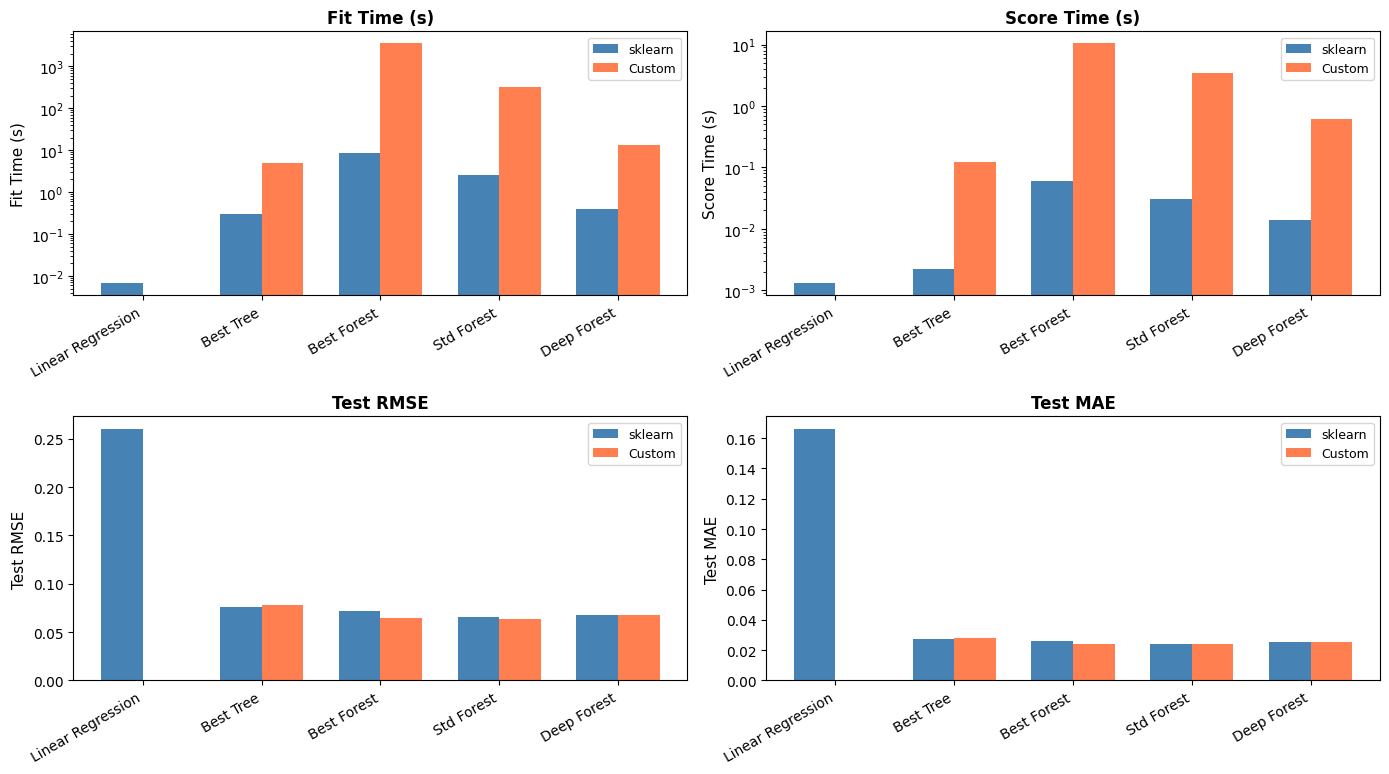

In [9]:
# Cross-Validation Comparison (2x2: Fit Time, Score Time, Test RMSE, Test MAE)
fig_cv = plot_cv_comparison(sklearn_cv_results, custom_cv_results, model_pairs, sklearn_only)
plt.show()

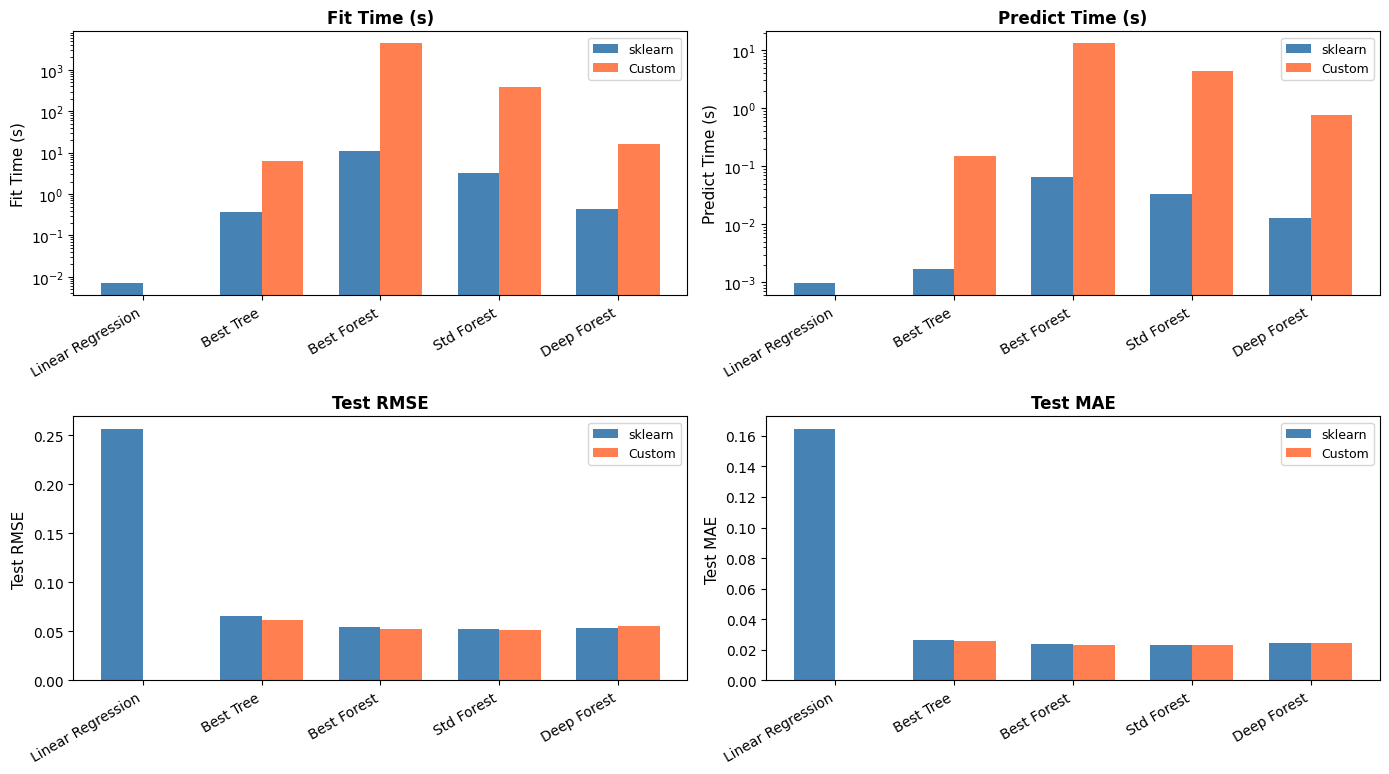

In [10]:
# Holdout Comparison (2x2: Fit Time, Predict Time, Test RMSE, Test MAE)
fig_ho = plot_holdout_comparison(sklearn_ho_results, custom_ho_results, model_pairs, sklearn_only)
plt.show()

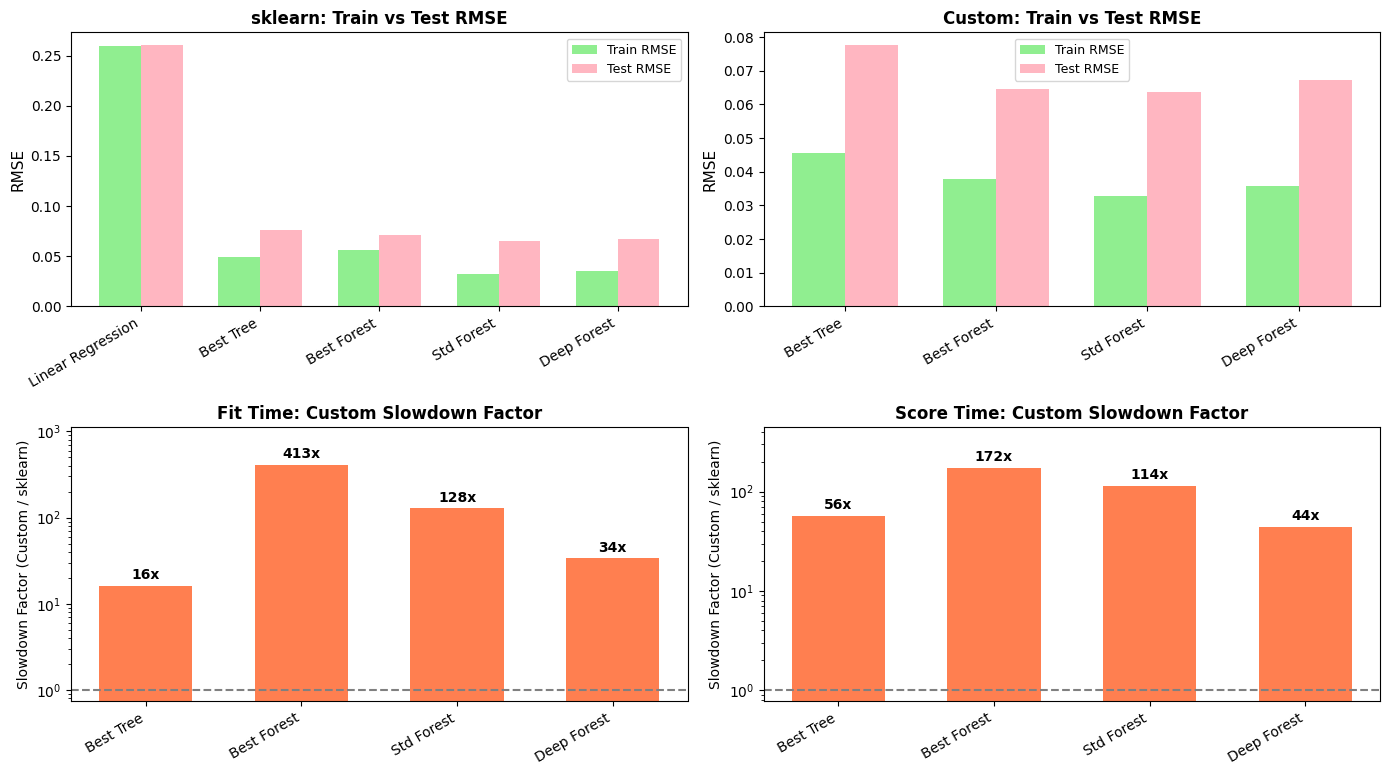

In [11]:
# Overfitting Analysis: Train vs Test RMSE
fig_overfit = plot_overfitting_comparison(sklearn_cv_results, custom_cv_results, model_pairs, sklearn_only)
plt.show()

### 5.1 Results Summary
### 5.2 Discussion and Insights